**Imports and Data Loading**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load datasets
patients = pd.read_csv('patients.csv')
conditions = pd.read_csv('conditions.csv')

# Load large files (if available)
try:
    observations = pd.read_csv('observations.csv')
    encounters = pd.read_csv('encounters.csv')
    print("All files loaded successfully.")
except FileNotFoundError:
    print("Note: observations.csv or encounters.csv missing. Model will use demographic data only.")
    observations = pd.DataFrame()
    encounters = pd.DataFrame()

Note: observations.csv or encounters.csv missing. Model will use demographic data only.


Target Labeling (Chronic Diseases)

In [13]:
# Define keywords for the 5 chronic diseases
target_groups = {
    'diabetes': 'Diabetes|Prediabetes',
    'ckd': 'Kidney|Renal|Nephropathy',
    'cardiovascular': 'Hypertension|Heart|Infarction|Atrial|Coronary|Ischemic',
    'anemia': 'Anemia',
    'liver_disease': 'Liver|Cirrhosis|Hepatitis'
}

# Create search pattern
chronic_pattern = '|'.join(target_groups.values())

# Find patient IDs with these conditions
chronic_ids = conditions[conditions['DESCRIPTION'].str.contains(chronic_pattern, case=False, na=False)]['PATIENT'].unique()

# Create a clean Target mapping
target_df = pd.DataFrame({'Id': patients['Id']})
target_df['target'] = target_df['Id'].isin(chronic_ids).astype(int)

print(f"Target count: \n{target_df['target'].value_counts()}")

Target count: 
target
1    1231
0    1089
Name: count, dtype: int64


Data Cleaning

In [14]:
def clean_demographics(df):
    # Keep only columns useful for modeling + Id for merging
    keep_cols = ['Id', 'BIRTHDATE', 'GENDER', 'RACE', 'INCOME', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE']
    df = df[keep_cols].copy()

    # Calculate Age
    df['BIRTHDATE'] = pd.to_datetime(df['BIRTHDATE'])
    df['Age'] = 2024 - df['BIRTHDATE'].dt.year

    # Encode Gender (M=0, F=1)
    df['GENDER'] = df['GENDER'].map({'M': 0, 'F': 1})

    # One-Hot Encode Race
    df = pd.get_dummies(df, columns=['RACE'], prefix='race', drop_first=True)

    # Drop BIRTHDATE
    df = df.drop(columns=['BIRTHDATE'])

    return df

patients_cleaned = clean_demographics(patients)

Feature Engineering

In [15]:
# 1. Process Observations (Vitals)
if not observations.empty:
    # LOINC Codes: Glucose, HbA1c, Systolic BP, Creatinine, Hemoglobin
    relevant_codes = ['2339-0', '4548-4', '8480-6', '2160-0', '718-7']
    obs_filtered = observations[observations['CODE'].isin(relevant_codes)]

    # Get latest value per patient per test
    obs_latest = obs_filtered.sort_values('DATE').groupby(['PATIENT', 'DESCRIPTION'])['VALUE'].last().unstack()
    obs_latest.columns = [col.replace(' ', '_').lower() for col in obs_latest.columns]
    obs_latest = obs_latest.reset_index().rename(columns={'PATIENT': 'Id'})
else:
    obs_latest = pd.DataFrame(columns=['Id'])

# 2. Process Encounters (Visit Frequency)
if not encounters.empty:
    encounter_counts = encounters.groupby('PATIENT')['Id'].count().reset_index()
    encounter_counts.columns = ['Id', 'visit_count']
else:
    encounter_counts = pd.DataFrame(columns=['Id', 'visit_count'])

# --- MASTER MERGE ---
# Start with the target labels
df_final = target_df.merge(patients_cleaned, on='Id', how='left')
df_final = df_final.merge(obs_latest, on='Id', how='left')
df_final = df_final.merge(encounter_counts, on='Id', how='left')

# Final Cleaning
df_final = df_final.fillna(0)
model_data = df_final.drop(columns=['Id'])

print(f"Final dataset shape: {model_data.shape}")
print(f"Columns in model: {model_data.columns.tolist()}")

Final dataset shape: (2320, 12)
Columns in model: ['target', 'GENDER', 'INCOME', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'Age', 'race_black', 'race_hawaiian', 'race_native', 'race_other', 'race_white', 'visit_count']


Model Training & Evaluation

In [16]:
# Separate Features and Target
X = model_data.drop('target', axis=1)
y = model_data['target']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Metrics
y_pred = model.predict(X_test)
print("--- Model Accuracy ---")
print(f"Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Model Accuracy ---
Score: 0.79

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       216
           1       0.79      0.83      0.81       248

    accuracy                           0.79       464
   macro avg       0.79      0.79      0.79       464
weighted avg       0.79      0.79      0.79       464



Feature Importance

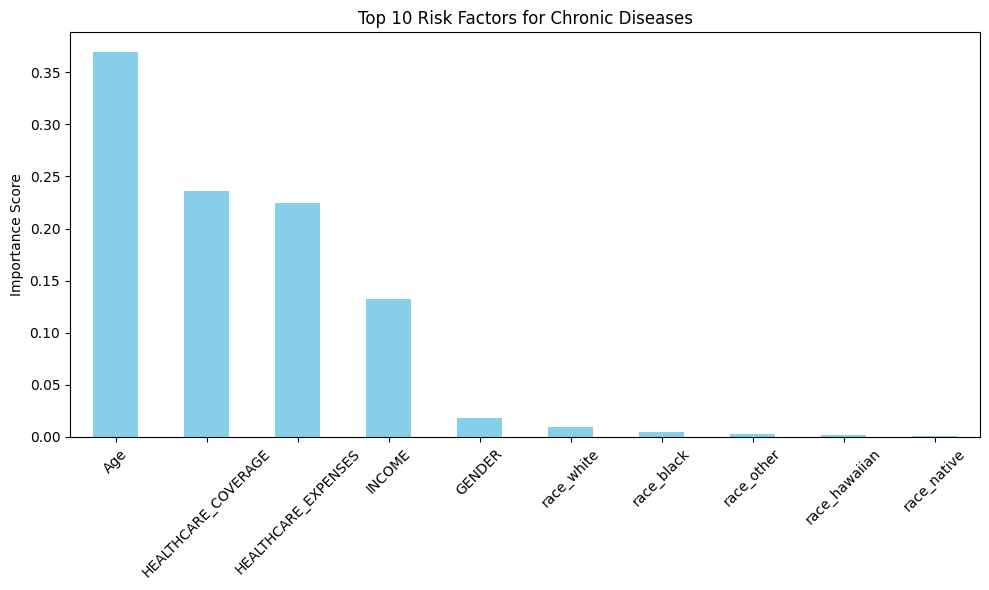

In [17]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Risk Factors for Chronic Diseases")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
import pickle

# 1. Save your Random Forest Model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# 2. IMPORTANT: Save your Scaler (if you used one for your California data)
# If you used something like: scaler = StandardScaler().fit(X_train)
# with open('scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

print("Pickle files created!")

Pickle files created!


In [19]:
import pickle

# 1. Save your Random Forest Model with the specific './' path
with open('./random_forest_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Pickle file created in the current folder!")

Pickle file created in the current folder!


In [20]:
from sklearn.linear_model import LogisticRegression
import pickle

# 1. Initialize and Train Logistic Regression
# (We use the same X_train and y_train from your Random Forest)
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

# 2. Save this one as a separate pickle file
with open('./logistic_model.pkl', 'wb') as f:
    pickle.dump(log_model, f)

print("Logistic Regression model trained and 'logistic_model.pkl' created!")

Logistic Regression model trained and 'logistic_model.pkl' created!


Lasso REgression

In [21]:
from sklearn.linear_model import LogisticRegression

# --- Logistic Regression ---
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)
with open('./logistic_model.pkl', 'wb') as f:
    pickle.dump(log_model, f)

# --- Lasso (L1 Regularization) ---
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, class_weight='balanced')
lasso_model.fit(X_train, y_train)
with open('./lasso_model.pkl', 'wb') as f:
    pickle.dump(lasso_model, f)

print("Logistic and Lasso models saved!")

Logistic and Lasso models saved!


C:\Users\nalla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\nalla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


XG Boost

In [24]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   -- ------------------------------------- 5.5/101.7 MB 19.9 MB/s eta 0:00:05
   ----- ---------------------------------- 13.1/101.7 MB 27.4 MB/s eta 0:00:04
   ------ --------------------------------- 16.8/101.7 MB 28.7 MB/s eta 0:00:03
   ------- -------------------------------- 18.1/101.7 MB 20.4 MB/s eta 0:00:05
   -------- ------------------------------- 21.0/101.7 MB 20.6 MB/s eta 0:00:04
   --------- ------------------------------ 24.6/101.7 MB 19.0 MB/s eta 0:00:05
   ------------ --------------------------- 32.5/101.7 MB 21.4 MB/s eta 0:00:04
   -------------- ------------------------- 37.5/101.7 MB 22.0 MB/s eta 0:00:03
   ----------------- ---------------------- 45.1/101.7 MB 23.3 MB/s eta 0:00:03
   ------------------- -------------------- 49.8/101.7 MB 24.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\nalla\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [26]:
import pandas as pd

# 1. Convert 'visit_count' to numeric (this turns strings like "5" into the number 5)
X_train['visit_count'] = pd.to_numeric(X_train['visit_count'], errors='coerce')
X_test['visit_count'] = pd.to_numeric(X_test['visit_count'], errors='coerce')

# 2. If there were any actual text words in there, they are now 'NaN' (empty). 
# We fill those with 0 so the model doesn't crash.
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("Data types fixed! Now run the XGBoost cell again.")

Data types fixed! Now run the XGBoost cell again.


In [27]:
from xgboost import XGBClassifier
import pickle

# --- XGBoost ---
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Save the pickle file
with open('./xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("XGBoost model trained and 'xgboost_model.pkl' created!")

XGBoost model trained and 'xgboost_model.pkl' created!


C:\Users\nalla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [22:03:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
